# MolCrysKit Ideal Polyhedra Gallery

This notebook serves two purposes:

1. **Reference catalogue** — visualise every ideal coordination polyhedron registered in `mck.structures.polyhedra` for CN=4 through CN=12. Vertices are black dots, convex-hull faces are translucent triangles, hull edges are solid lines. These coordinates are unit-sphere-normalised angular reference geometries used by `packing_shell.angular_rmsd_vs_ideals` for shape scoring, not physical crystal-scale distances.
2. **Practical workflow** — show how to extract real A--B coordination polyhedra from a crystal with `mck.analysis.find_polyhedra`, and how the three CN-selection modes (gap, gap+enclosure, cutoff) differ.

Sections:
- Full Gallery — auto-generated from the registry
- Single-Polyhedron Close-Up — pick any registered name
- Same-CN Comparisons — CN=8 (cube vs antiprism vs dodecahedron) and CN=11 (including the newly registered tricapped cube)
- Finding A--B Polyhedra in a Real Crystal — `find_polyhedra` walk-through on `examples/MAP.cif`
- Mode Comparison: gap vs gap+enclosure vs cutoff — same input, three answers

In [ ]:
%matplotlib inline

import math
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
from scipy.spatial import ConvexHull, QhullError

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name in {"notebook", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import molcrys_kit as mck
from molcrys_kit.structures.polyhedra import (
    get_polyhedron,
    ideal_polyhedra_for_cn,
    list_polyhedra,
)
from molcrys_kit.analysis import (
    detect_coordination_number,
    find_polyhedra,
)
from molcrys_kit.io.cif import read_mol_crystal

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 10,
})

In [2]:
def _all_pair_edges(n_points):
    """Fallback edge list for inputs that cannot form a 2-D or 3-D hull."""
    return [tuple(edge) for edge in combinations(range(n_points), 2)]


def _coplanar_edges(vertices, *, tol=1e-10):
    """Return outline edges for coplanar points by projecting them to 2-D."""
    if len(vertices) < 4:
        return _all_pair_edges(len(vertices))

    centered = vertices - vertices.mean(axis=0)
    _, singular_values, vh = np.linalg.svd(centered, full_matrices=False)
    rank = int(np.sum(singular_values > tol))
    if rank < 2:
        return _all_pair_edges(len(vertices))

    basis = vh[:2].T
    projected = centered @ basis
    try:
        hull_2d = ConvexHull(projected)
    except QhullError:
        return _all_pair_edges(len(vertices))

    outline = list(hull_2d.vertices)
    return sorted(
        tuple(sorted((int(outline[i]), int(outline[(i + 1) % len(outline)]))))
        for i in range(len(outline))
    )


def _hull_geometry(vertices):
    """Return hull triangles and edge-index pairs for a set of vertices."""
    vertices = np.asarray(vertices, dtype=float)
    if len(vertices) < 4:
        return [], _all_pair_edges(len(vertices))

    try:
        hull = ConvexHull(vertices)
    except QhullError:
        return [], _coplanar_edges(vertices)

    triangles = [vertices[simplex] for simplex in hull.simplices]
    edges = set()
    for simplex in hull.simplices:
        for i, j in combinations(simplex, 2):
            edges.add(tuple(sorted((int(i), int(j)))))
    return triangles, sorted(edges)

In [3]:
def _set_clean_3d_axes(ax, *, limit=1.15):
    """Use fixed limits so every reference shape appears at the same scale."""
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_alpha(0.0)
        axis._axinfo["grid"]["linewidth"] = 0.0


def _draw_unit_sphere(ax, *, radius=1.0):
    """Draw a faint unit-sphere wireframe for close-up reference plots."""
    theta = np.linspace(0.0, 2.0 * math.pi, 48)
    phi = np.linspace(0.0, math.pi, 24)
    x = radius * np.outer(np.cos(theta), np.sin(phi))
    y = radius * np.outer(np.sin(theta), np.sin(phi))
    z = radius * np.outer(np.ones_like(theta), np.cos(phi))
    ax.plot_wireframe(x, y, z, color="0.8", linewidth=0.3, alpha=0.25)


def plot_polyhedron(ax, poly, *, show_sphere=False):
    """Plot one IdealPolyhedron on a 3-D matplotlib axes."""
    vertices = np.asarray(poly.vertices, dtype=float)
    triangles, edges = _hull_geometry(vertices)

    if triangles:
        faces = Poly3DCollection(
            triangles,
            facecolors="#4C78A8",
            edgecolors="none",
            linewidths=0.0,
            alpha=0.18,
        )
        ax.add_collection3d(faces)

    if edges:
        segments = [(vertices[i], vertices[j]) for i, j in edges]
        ax.add_collection3d(
            Line3DCollection(segments, colors="#2F4B7C", linewidths=1.3, alpha=0.9)
        )

    ax.scatter(
        vertices[:, 0],
        vertices[:, 1],
        vertices[:, 2],
        s=24,
        c="black",
        depthshade=True,
    )

    if show_sphere:
        _draw_unit_sphere(ax)

    ax.set_title(f"{poly.name}\nCN={poly.cn}, {poly.point_group}, {poly.category}")
    ax.view_init(elev=22, azim=38)
    _set_clean_3d_axes(ax)


def plot_real_polyhedron(
    ax,
    center,
    shell_coords,
    *,
    title=None,
    central_color="#C0392B",
    ligand_color="black",
    face_color="#4C78A8",
    edge_color="#2F4B7C",
):
    """Plot a real-crystal coordination polyhedron with central atom marker.

    Unlike :func:`plot_polyhedron`, axes are auto-scaled to the shell extent,
    because real polyhedra are not unit-sphere-normalised.
    """
    center = np.asarray(center, dtype=float)
    shell = np.asarray(shell_coords, dtype=float)

    triangles, edges = _hull_geometry(shell)

    if triangles:
        faces = Poly3DCollection(
            triangles,
            facecolors=face_color,
            edgecolors="none",
            linewidths=0.0,
            alpha=0.18,
        )
        ax.add_collection3d(faces)
    if edges:
        segments = [(shell[i], shell[j]) for i, j in edges]
        ax.add_collection3d(
            Line3DCollection(segments, colors=edge_color, linewidths=1.3, alpha=0.9)
        )
    # Bonds from center to ligands
    bonds = [(center, p) for p in shell]
    if bonds:
        ax.add_collection3d(
            Line3DCollection(bonds, colors="0.5", linewidths=0.8, alpha=0.6)
        )

    if len(shell):
        ax.scatter(
            shell[:, 0], shell[:, 1], shell[:, 2],
            s=44, c=ligand_color, depthshade=True,
        )
    ax.scatter(
        [center[0]], [center[1]], [center[2]],
        s=72, c=central_color, depthshade=True, edgecolors="white", linewidths=0.8,
    )

    if title:
        ax.set_title(title)
    ax.view_init(elev=22, azim=38)

    pts = np.vstack([shell, center[None, :]]) if len(shell) else center[None, :]
    span = max(float(np.ptp(pts[:, k])) for k in range(3))
    pad = 0.15 * span if span > 0 else 1.0
    cx, cy, cz = center
    half = (span / 2.0) + pad if span > 0 else 1.0
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_zlim(cz - half, cz + half)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_alpha(0.0)
        axis._axinfo["grid"]["linewidth"] = 0.0

## Full Gallery

The gallery below is generated directly from `list_polyhedra()`, so new registry entries appear automatically the next time the notebook is run.

Rendered 21 registered polyhedra.


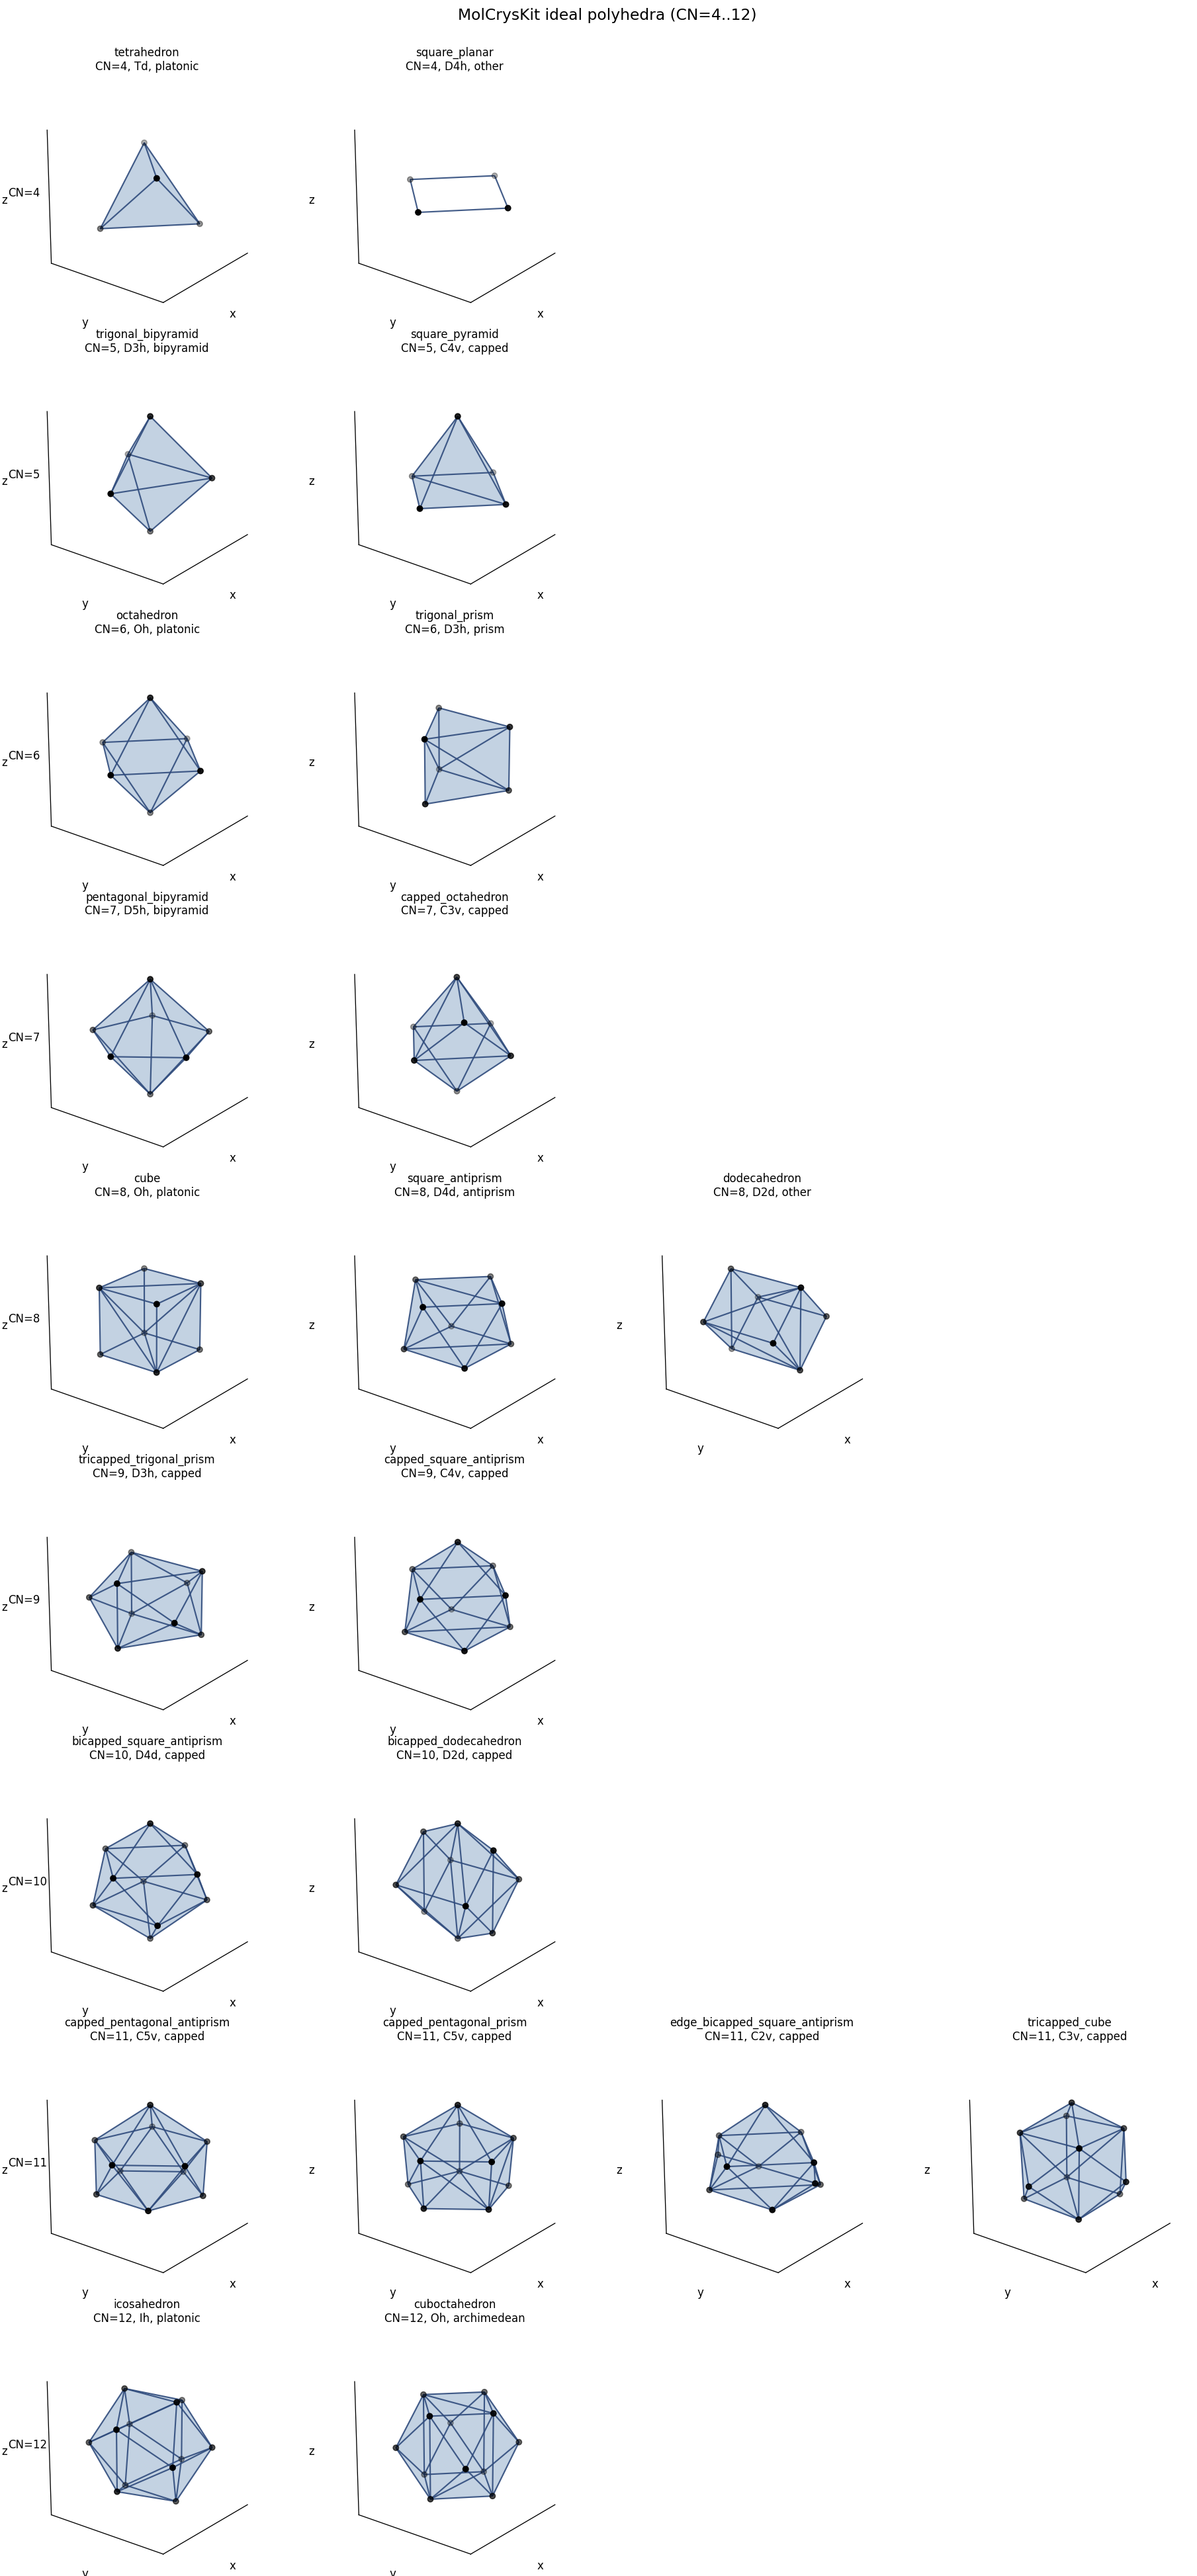

In [4]:
polys = list_polyhedra()
by_cn = {
    cn: [poly for poly in polys if poly.cn == cn]
    for cn in sorted({poly.cn for poly in polys})
}

ncols = max(len(items) for items in by_cn.values())
nrows = len(by_cn)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.0 * ncols, 3.6 * nrows),
    subplot_kw={"projection": "3d"},
    squeeze=False,
)

for r, (cn, items) in enumerate(by_cn.items()):
    for c in range(ncols):
        ax = axes[r, c]
        if c < len(items):
            plot_polyhedron(ax, items[c])
        else:
            ax.set_axis_off()
    axes[r, 0].text2D(-0.08, 0.5, f"CN={cn}", transform=axes[r, 0].transAxes)

fig.suptitle("MolCrysKit ideal polyhedra (CN=4..12)", y=1.0, fontsize=14)
plt.tight_layout()
rendered_count = sum(len(items) for items in by_cn.values())
print(f"Rendered {rendered_count} registered polyhedra.")

## Single-Polyhedron Close-Up

Change the `name` variable to any registered polyhedron name to inspect it with a faint unit-sphere wireframe.

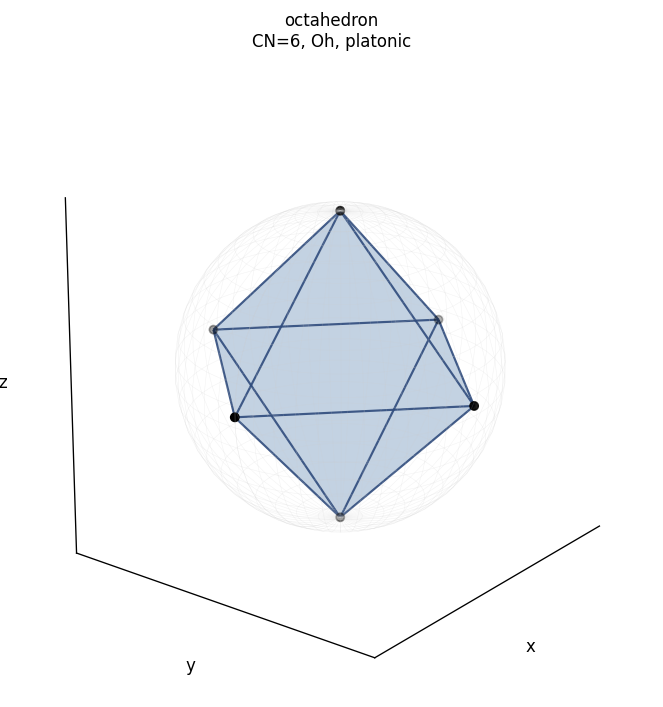

In [5]:
name = "octahedron"
poly = get_polyhedron(name)
if poly is None:
    raise ValueError(f"Unknown polyhedron: {name}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
plot_polyhedron(ax, poly, show_sphere=True)
plt.tight_layout()

## Same-CN Comparison: CN=8

CN=8 has three registered candidates. Viewing them side by side gives an intuitive feel for what the angular-RMSD comparison in `packing_shell.angular_rmsd_vs_ideals` distinguishes. A second comparison for CN=11 follows below, since the recent `tricapped_cube` registration adds a fourth distinct shape there.

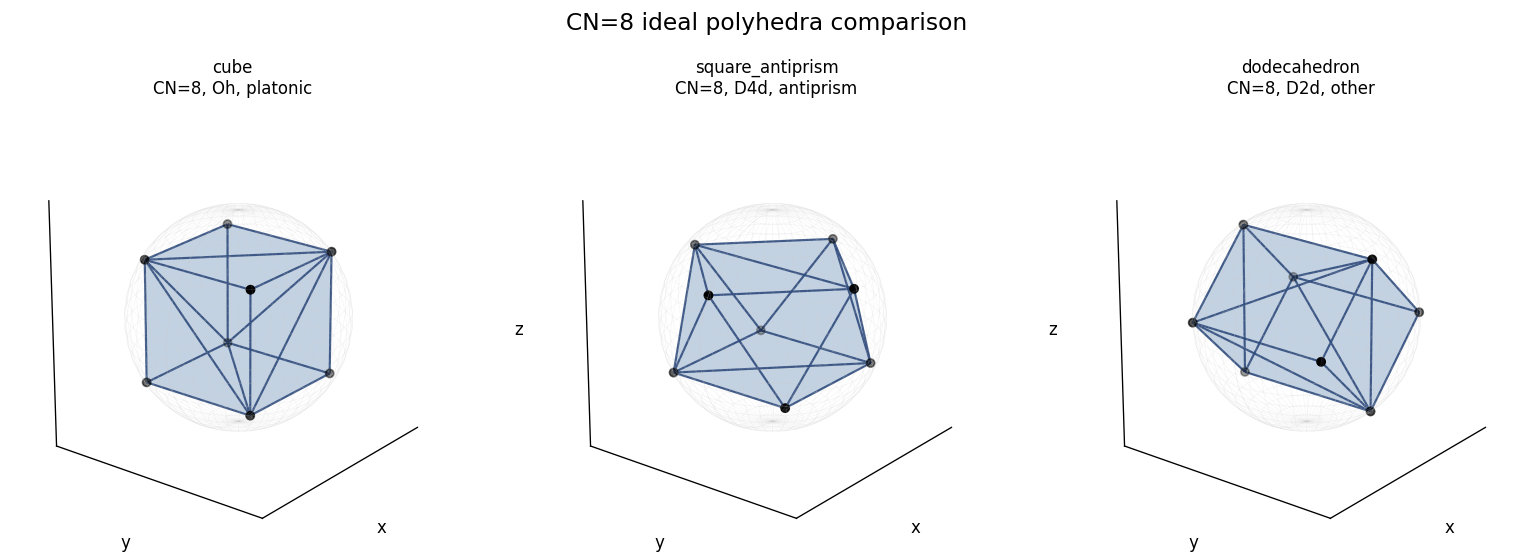

In [6]:
cn8_names = ("cube", "square_antiprism", "dodecahedron")
cn8_polys = [get_polyhedron(name) for name in cn8_names]
if any(poly is None for poly in cn8_polys):
    missing = [name for name, poly in zip(cn8_names, cn8_polys) if poly is None]
    raise ValueError(f"Missing CN=8 polyhedra: {missing}")

fig, axes = plt.subplots(
    1,
    len(cn8_polys),
    figsize=(4.5 * len(cn8_polys), 4.5),
    subplot_kw={"projection": "3d"},
)
for ax, poly in zip(axes, cn8_polys):
    plot_polyhedron(ax, poly, show_sphere=True)

fig.suptitle("CN=8 ideal polyhedra comparison", y=1.02, fontsize=14)
plt.tight_layout()

## CN=11 Comparison: tricapped cube vs the others

CN=11 was historically the noisiest entry in the catalogue because it has multiple plausible references. The recent registration of **`tricapped_cube`** (C3v) — a cube with three caps on the orthogonal faces meeting at the (1,1,1) corner — covers a coordination motif that the existing pentagonal-prism and edge-bicapped square-antiprism candidates fit poorly: lanthanide/actinide complexes and hydrogen-bonded inorganic-cation shells (e.g. ClO4-around an A2BX5 A-site).

Side-by-side with the other CN=11 references it is visually distinct from the pentagonal family.

CN=11 candidates: ['capped_pentagonal_antiprism', 'capped_pentagonal_prism', 'edge_bicapped_square_antiprism', 'tricapped_cube']


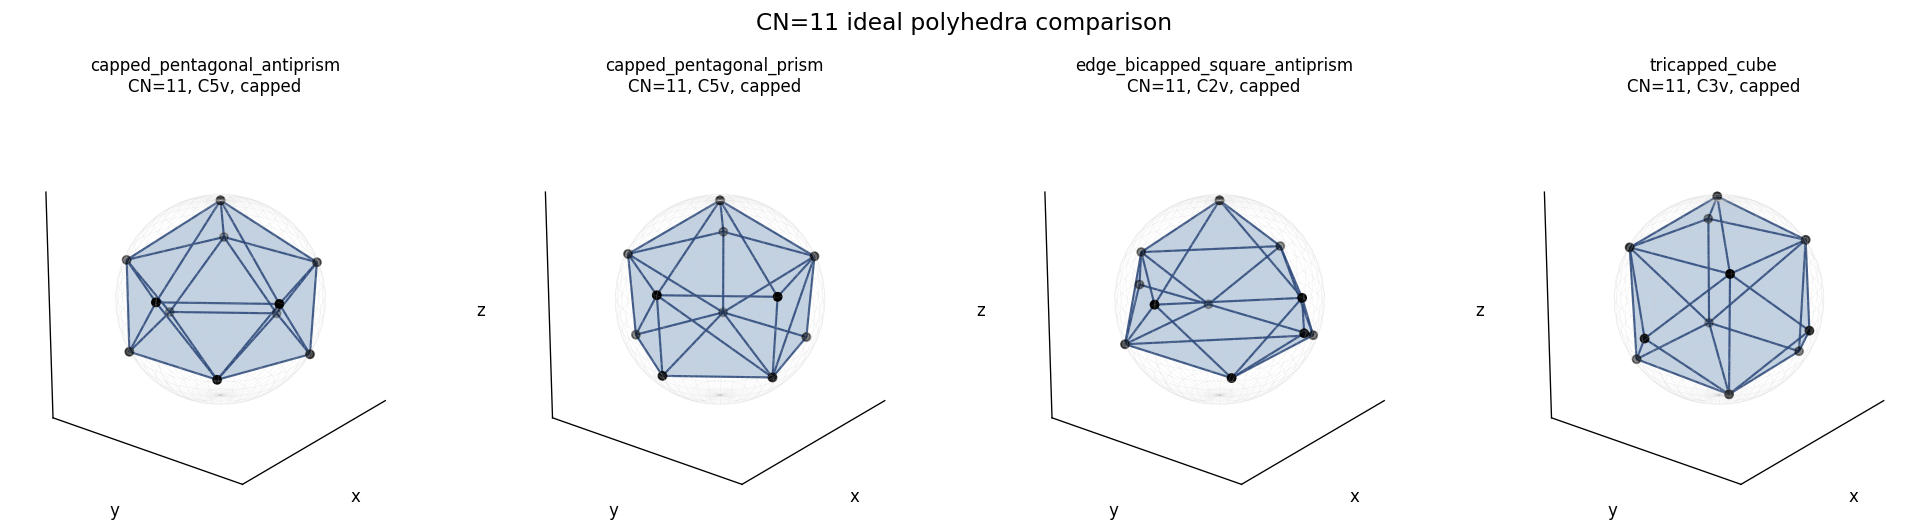

In [7]:
cn11_polys = list(ideal_polyhedra_for_cn(11).keys())
print(f"CN=11 candidates: {cn11_polys}")

cn11_objs = [get_polyhedron(name) for name in cn11_polys]

ncols = len(cn11_objs)
fig, axes = plt.subplots(
    1, ncols,
    figsize=(4.2 * ncols, 4.2),
    subplot_kw={"projection": "3d"},
    squeeze=False,
)
for ax, poly in zip(axes[0], cn11_objs):
    plot_polyhedron(ax, poly, show_sphere=True)

fig.suptitle("CN=11 ideal polyhedra comparison", y=1.02, fontsize=14)
plt.tight_layout()

## Finding A--B Polyhedra in a Real Crystal

`mck.analysis.find_polyhedra(structure, central, ligand, ...)` extracts coordination polyhedra straight from a `MolecularCrystal` (or any ASE `Atoms`-like object). It enumerates PBC-aware neighbours and admits **only** atoms whose symbol matches `ligand`, so non-ligand species — including other A atoms that may happen to fall inside the candidate hull — never enter the shell.

Below we use `examples/MAP.cif` (a methylammonium perchlorate variant) and look at the Cl--O coordination shell. With a hard cutoff `r_c = 2.0 Å` we get clean ClO4 tetrahedra without manual gap inspection.

In [ ]:
cif_path = PROJECT_ROOT / "examples" / "MAP.cif"
crystal = mck.read_mol_crystal(str(cif_path))

cl_o_polys = find_polyhedra(
    crystal,
    central="Cl",
    ligand="O",
    cutoff=2.0,
    score_shape=True,
)

print(f"Found {len(cl_o_polys)} Cl--O polyhedra in {cif_path.name}")
print()
print(f"{'idx':>4} {'CN':>3} {'mode':<14} {'best match':<14} {'rmsd (deg)':>10} {'min d (A)':>10} {'max d (A)':>10}")
for record in cl_o_polys[:5]:
    bm = record["best_match"] or {"name": "-", "angular_rmsd": float('nan')}
    dists = record["shell_distances"]
    print(
        f"{record['center_index']:>4d} "
        f"{record['coordination_number']:>3d} "
        f"{record['mode']:<14} "
        f"{bm['name']:<14} "
        f"{bm['angular_rmsd']:>10.3f} "
        f"{min(dists):>10.3f} "
        f"{max(dists):>10.3f}"
    )

Found 8 Cl--O polyhedra in MAP.cif

 idx  CN mode           best match     rmsd (deg)  min d (A)  max d (A)
  18   4 cutoff         tetrahedron         1.169      1.400      1.468
  23   4 cutoff         tetrahedron         1.169      1.400      1.468
  28   4 cutoff         tetrahedron         1.169      1.400      1.468
  33   4 cutoff         tetrahedron         1.169      1.400      1.468
  39   4 cutoff         tetrahedron         2.348      1.377      1.462


C:\Users\gmy72\.cursor\worktrees\MolCrysKit\mkx\molcrys_kit\io\cif.py:620: UserWarning: The default value of primitive was changed from True to False in https://github.com/materialsproject/pymatgen/pull/3419. CifParser now returns the cell in the CIF file as is. If you want the primitive cell, please set primitive=True explicitly.
  structures = parser.parse_structures()
C:\Users\gmy72\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymatgen\io\cif.py:1314: UserWarning: Missing elements H from PMG structure composition
  if struct := self._get_structure(data, primitive, symmetrized, check_occu=check_occu):


### Visualise one extracted ClO4 polyhedron

`record["shell_coords"]` already contains the PBC-corrected ligand positions, so we can hand them straight to a 3-D plot together with the central atom.

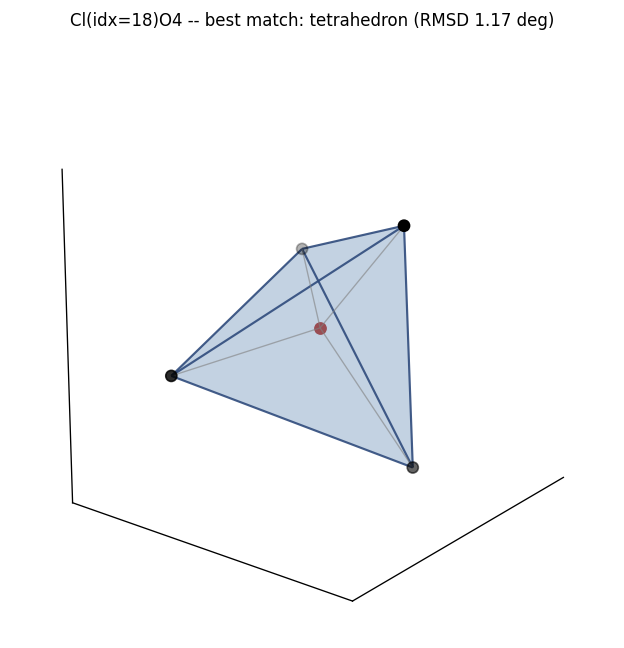

In [9]:
first = cl_o_polys[0]

fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
plot_real_polyhedron(
    ax,
    center=first["center_position"],
    shell_coords=first["shell_coords"],
    title=(
        f"Cl(idx={first['center_index']})O{first['coordination_number']} "
        f"-- best match: {first['best_match']['name']} "
        f"(RMSD {first['best_match']['angular_rmsd']:.2f} deg)"
    ),
)
plt.tight_layout()

## Mode Comparison: gap vs gap+enclosure vs cutoff

`detect_coordination_number` exposes three CN-selection modes. They can disagree on the same neighbour list, especially when the central atom sits off-centre relative to the closest few ligands. We use the off-centre 12-atom shell from the regression test in `tests/unit/test_packing_shell.py` to make all three modes visible at once:

- **`gap`** stops at the largest distance gap (here CN=4) — the "honest A--B" answer.
- **`gap+enclosure`** (the historical default) keeps adding atoms past the gap until the convex hull wraps the central atom (here CN=12).
- **`cutoff=r_c`** takes everything within `r_c` Å regardless of gaps and never expands beyond it — the "I trust my radius" answer.

Sorted A--B distances: [4.817, 4.868, 5.254, 5.468, 8.781, 8.853, 8.932, 8.932, 8.963, 8.993, 9.098, 9.098]
mode                    CN   enclosed   expanded
gap                      4      False      False
gap+enclosure           12       True       True
cutoff (r_c=9.0 A)      10      False      False


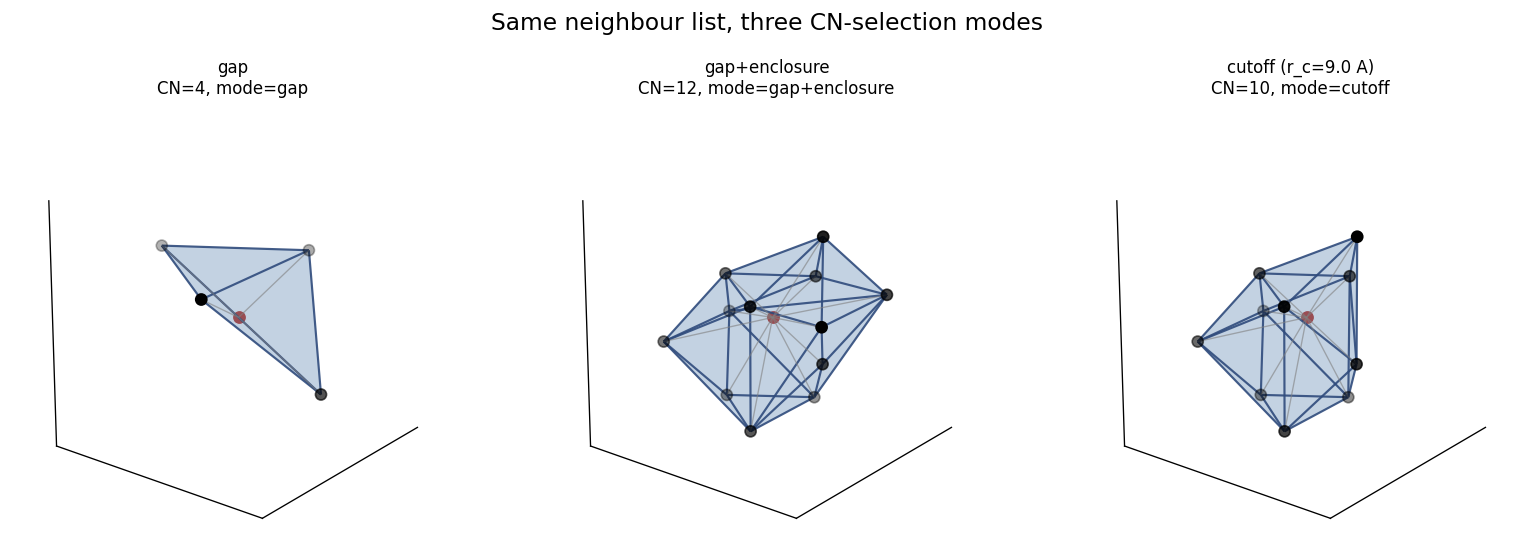

In [10]:
demo_coords = np.array(
    [
        [-4.04,  1.06,  2.40],
        [ 4.08,  1.07,  2.43],
        [ 0.00, -4.61,  2.52],
        [ 0.00,  4.80, -2.62],
        [-3.97,  1.06, -7.76],
        [ 4.07,  1.06, -7.79],
        [ 0.00, -4.57, -7.71],
        [-4.04, -7.53, -2.60],
        [ 4.04, -7.53, -2.60],
        [ 0.00,  4.76,  7.63],
        [-4.10,  7.74,  2.46],
        [ 4.10,  7.74,  2.46],
    ],
    dtype=float,
)
demo_center = np.zeros(3)
demo_distances = np.linalg.norm(demo_coords - demo_center, axis=1)
order = np.argsort(demo_distances)
demo_coords = demo_coords[order]
demo_distances = demo_distances[order]

modes = {
    "gap": dict(enforce_enclosure=False),
    "gap+enclosure": dict(enforce_enclosure=True),
    "cutoff (r_c=9.0 A)": dict(enforce_enclosure=True, cutoff=9.0),
}

print(f"Sorted A--B distances: {[round(float(d), 3) for d in demo_distances]}")
print(f"{'mode':<22} {'CN':>3}  {'enclosed':>9}  {'expanded':>9}")
results = {}
for label, kwargs in modes.items():
    info = detect_coordination_number(
        demo_distances,
        coords=demo_coords,
        center=demo_center,
        **kwargs,
    )
    results[label] = info
    print(
        f"{label:<22} {info['coordination_number']:>3d}  "
        f"{str(info['enclosed']):>9}  {str(info['enclosure_expanded']):>9}"
    )

fig, axes = plt.subplots(
    1, len(results),
    figsize=(4.5 * len(results), 4.5),
    subplot_kw={"projection": "3d"},
    squeeze=False,
)
for ax, (label, info) in zip(axes[0], results.items()):
    cn = info["coordination_number"]
    plot_real_polyhedron(
        ax,
        center=demo_center,
        shell_coords=demo_coords[:cn],
        title=f"{label}\nCN={cn}, mode={info['mode']}",
    )

fig.suptitle(
    "Same neighbour list, three CN-selection modes",
    y=1.02, fontsize=14,
)
plt.tight_layout()

## Notes

"- **Adding a new ideal polyhedron**: register it in `mck.structures.polyhedra`. The full gallery is driven by `list_polyhedra()`, so it appears automatically; the same is true for the per-CN comparisons (`ideal_polyhedra_for_cn`).\n",
    "- **Normalisation**: the gallery and same-CN plots use unit-sphere-normalised angular reference geometries, identical to what `mck.analysis.packing_shell.angular_rmsd_vs_ideals` consumes. Capped and other asymmetric references may have centroids that are not exactly at the origin; subplots use fixed unit-sphere limits so visual scale stays comparable.\n",
- **Real-crystal polyhedra**: `find_polyhedra` returns dicts with `shell_coords` already in Cartesian crystal coordinates (PBC offsets applied), so `plot_real_polyhedron` (defined above) can render them without additional bookkeeping.
- **Choosing a CN-selection mode** (`detect_coordination_number`):
  - Use **`cutoff=r_c`** when you want a hard radial criterion that ignores gaps and never silently expands. This is the cleanest A--B definition for downstream analysis.
  - Use **`enforce_enclosure=False`** when you want the gap-only CN — useful for square-planar or one-sided cages where the central atom genuinely is not centred.
  - Stay with the default (`gap+enclosure`) when you want the historical behaviour: gap heuristic with hull post-correction.
- **Element filtering**: `find_polyhedra(crystal, central, ligand, ...)` admits only atoms whose symbol matches `ligand`, so other A atoms (and any other element) cannot enter the polyhedron even if they fall geometrically inside the candidate hull.